# Section 3.1

## Example 3.1.1

Here are 5-year averages of the worldwide temperature anomaly as compared to the 1951–1980 average (source: NASA).

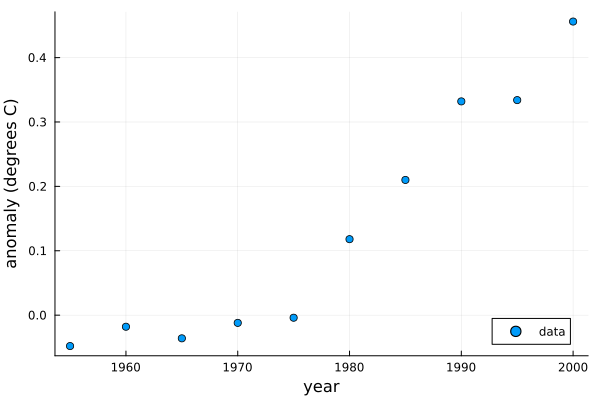

In [1]:
using Plots

year = 1955:5:2000
temp = [ -0.0480, -0.0180, -0.0360, -0.0120, -0.0040,
       0.1180, 0.2100, 0.3320, 0.3340, 0.4560 ]
    
scatter(year, temp, label="data",
    xlabel="year", ylabel="anomaly (degrees C)", legend=:bottomright)

In [2]:
t = @. (year - 1950) / 10
n = length(t)
V = [ t[i]^j for i in 1:n, j in 0:n-1 ]
c = V \ temp

10-element Vector{Float64}:
  -14.114000001832462
   76.36173810552113
 -165.45597224550528
  191.96056669514388
 -133.27347224319684
   58.015577787494486
  -15.962888891734785
    2.6948063497166928
   -0.2546666667177082
    0.010311111113288083

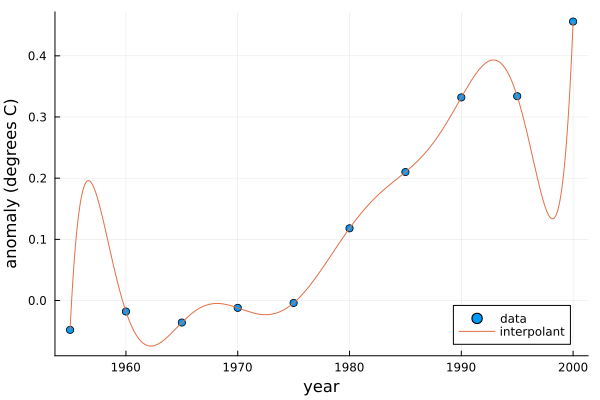

In [3]:
using Polynomials
p = Polynomial(c)
f(yr) = p((yr - 1950) / 10)
plot!(f, 1955, 2000, label="interpolant")

## Example 3.1.2 

In [4]:
using Plots
year = 1955:5:2000
t = @. (year - 1950) / 10
temp = [ -0.0480, -0.0180, -0.0360, -0.0120, -0.0040,
          0.1180, 0.2100, 0.3320, 0.3340, 0.4560 ]

10-element Vector{Float64}:
 -0.048
 -0.018
 -0.036
 -0.012
 -0.004
  0.118
  0.21
  0.332
  0.334
  0.456

In [5]:
using Polynomials
V = [ t.^0 t.^1 ]    # Vandermonde-ish matrix
size(V)


(10, 2)

In [6]:
c = V \ temp
p = Polynomial(c)

Polynomial(-0.18773333333333356 + 0.11670303030303034*x)

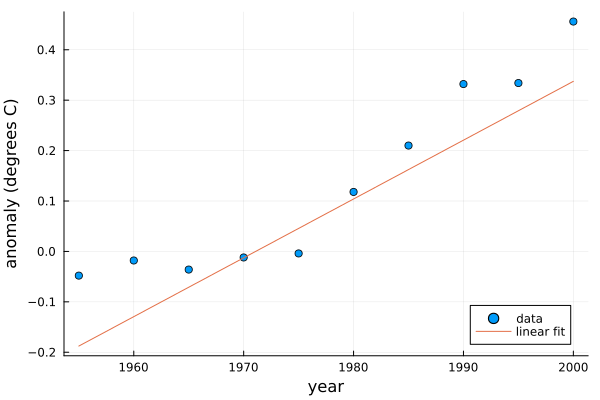

In [7]:
f(yr) = p((yr - 1955) / 10)

scatter(year, temp, label="data",
    xlabel="year", ylabel="anomaly (degrees C)", leg=:bottomright)
plot!(f, 1955, 2000, label="linear fit")

In [8]:
V = [ t[i]^j for i in 1:length(t), j in 0:3 ]   
size(V)

(10, 4)

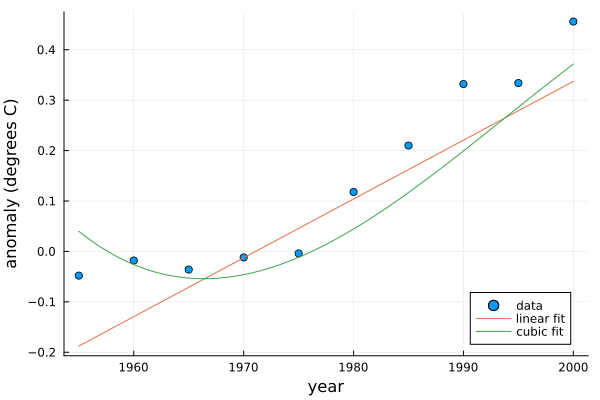

In [9]:
p = Polynomial( V \ temp )
plot!(f, 1955, 2000, label="cubic fit")

## Example 3.1.3

In [10]:
a = [1/k^2 for k in 1:100] 
s = cumsum(a)        # cumulative summation

100-element Vector{Float64}:
 1.0
 1.25
 1.3611111111111112
 1.4236111111111112
 1.4636111111111112
 1.4913888888888889
 1.511797052154195
 1.527422052154195
 1.5397677311665408
 1.5497677311665408
 ⋮
 1.6341233613246682
 1.6342389816275933
 1.6343521550092142
 1.6344629583333137
 1.6345714652777583
 1.6346777464978666
 1.6347818697798324
 1.6348839001848932
 1.6349839001848931

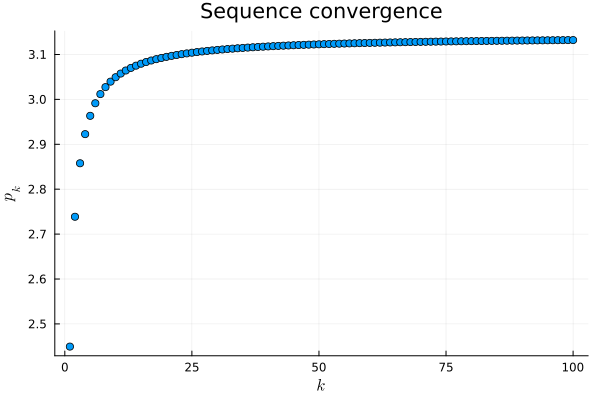

In [16]:
p = @. sqrt(6s)

using Plots, LaTeXStrings
scatter(1:100, p;
    title="Sequence convergence", xlabel=L"k",  ylabel=L"p_k", legend=false)

Plot the sequence of errors instead:

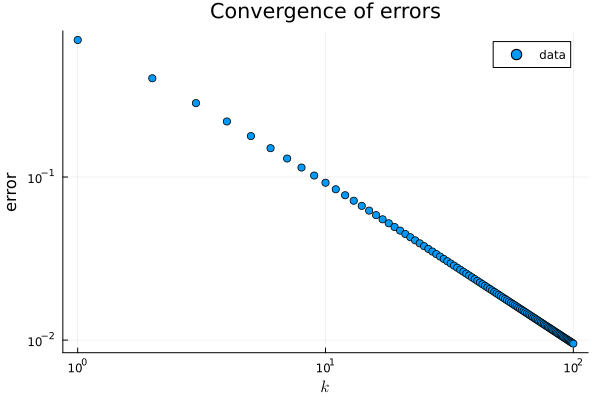

In [19]:
ϵ = @. abs(π - p)    # error sequence
scatter(1:100, ϵ;
    title="Convergence of errors", xaxis=(:log10, L"k"),  yaxis=(:log10, "error"), label="data")

$$
\begin{aligned}
\epsilon_k &\approx a k^b  \\ \log \epsilon_k &\approx b (\log k) + \log a 
\end{aligned}
$$

In [20]:
k = 1:100
V = [ k.^0 log.(k) ]     # fitting matrix
c = V \ log.(ϵ)          # coefficients of linear fit

2-element Vector{Float64}:
 -0.1823752497282998
 -0.9674103233127929

In [21]:
a, b = exp(c[1]), c[2]

(0.8332885904225789, -0.9674103233127929)

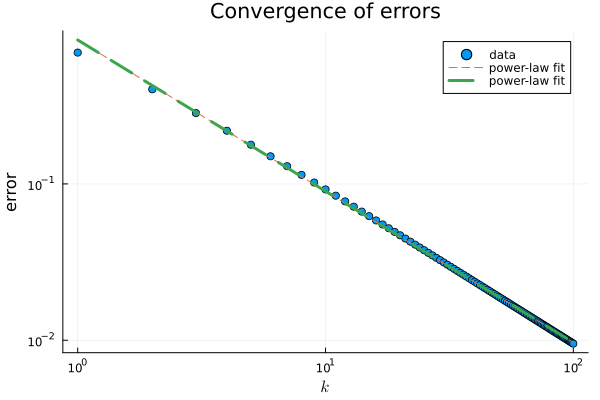

In [23]:
plot!(k, a * k.^b, l=(3, :dash), label="power-law fit")